# 02 — Chain Rule, Backpropagation & Automatic Differentiation ⭐

**The single highest-interview-yield notebook in the Calculus chapter.** "Derive backprop" or "explain how backprop works" is one of the most commonly asked ML questions, at every level of seniority.

**Book reference:** *Mathematics for Machine Learning* (Deisenroth, Faisal, Ong) — §5.5–5.8, pp.158–169 (Useful Identities for Computing Gradients, Backpropagation and Automatic Differentiation, Higher-Order Derivatives, Linearization and Multivariate Taylor Series)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
from pathlib import Path
%matplotlib inline

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

## Backprop is not a special algorithm — it's the chain rule, applied systematically

If `f(x) = h(g(x))`, the chain rule says `f'(x) = h'(g(x)) · g'(x)`. That's it. Backpropagation is exactly this rule, applied repeatedly through a **computational graph** — a graph where each node is an intermediate value, computed from its inputs.

Take a tiny example: `f = (x * y) + z`. Break it into a forward pass through two operations, `q = x*y` and `f = q+z`.

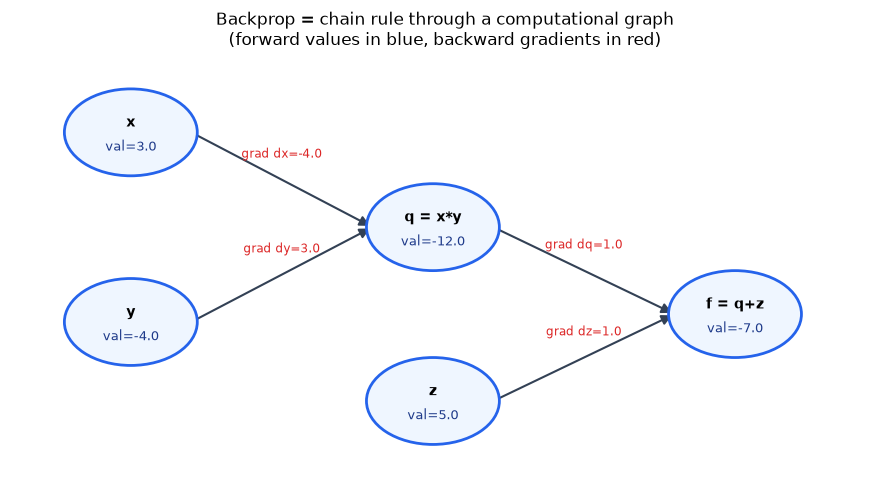

df/dx = -4.0, df/dy = 3.0, df/dz = 1.0


In [2]:
def visualize_computational_graph(savepath: Path = None):
    x, y, z = 3.0, -4.0, 5.0
    q = x * y          # forward
    f = q + z           # forward

    df_df = 1.0
    df_dq = df_df * 1.0     # d(f)/dq = 1 (addition just passes the gradient through)
    df_dz = df_df * 1.0     # d(f)/dz = 1
    df_dx = df_dq * y       # d(q)/dx = y  -> local derivative of multiplication
    df_dy = df_dq * x       # d(q)/dy = x

    fig, ax = plt.subplots(figsize=(9, 5))
    nodes = {"x": (0, 1.2), "y": (0, -1.2), "q = x*y": (2.5, 0),
             "z": (2.5, -2.2), "f = q+z": (5, -1.1)}
    values = {"x": x, "y": y, "q = x*y": q, "z": z, "f = q+z": f}

    for name, (px, py) in nodes.items():
        circ = Circle((px, py), 0.55, facecolor="#eff6ff", edgecolor="#2563eb", linewidth=2, zorder=3)
        ax.add_patch(circ)
        ax.text(px, py + 0.12, name, ha="center", va="center", fontsize=10, fontweight="bold", zorder=4)
        ax.text(px, py - 0.18, f"val={values[name]:.1f}", ha="center", va="center", fontsize=9, color="#1e3a8a", zorder=4)

    edges = [("x", "q = x*y", df_dx, "dx"), ("y", "q = x*y", df_dy, "dy"),
             ("q = x*y", "f = q+z", df_dq, "dq"), ("z", "f = q+z", df_dz, "dz")]
    for src, dst, grad, label in edges:
        sx, sy = nodes[src]; dx_, dy_ = nodes[dst]
        arrow = FancyArrowPatch((sx+0.5, sy), (dx_-0.5, dy_), arrowstyle="-|>", mutation_scale=15,
                                  color="#334155", linewidth=1.5, zorder=2, connectionstyle="arc3,rad=0.0")
        ax.add_patch(arrow)
        mx, my = (sx+dx_)/2, (sy+dy_)/2
        ax.text(mx, my + 0.28, f"grad {label}={grad:.1f}", ha="center", fontsize=8.5, color="#dc2626")

    ax.set_xlim(-1, 6.2); ax.set_ylim(-3.2, 2.2)
    ax.axis("off")
    ax.set_title("Backprop = chain rule through a computational graph\n(forward values in blue, backward gradients in red)")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()
    return df_dx, df_dy, df_dz

df_dx, df_dy, df_dz = visualize_computational_graph(FIG_DIR / "computational_graph.png")
print(f"df/dx = {df_dx}, df/dy = {df_dy}, df/dz = {df_dz}")

Two passes:
- **Forward pass** (blue values): compute `q = x*y = -12`, then `f = q+z = -7`, left to right.
- **Backward pass** (red gradients): start from `df/df = 1` at the output, and multiply local derivatives backward through each node — `df/dq = 1` (addition just passes the gradient through unchanged), then `df/dx = df/dq · dq/dx = 1 · y = -4` and `df/dy = df/dq · dq/dy = 1 · x = 3`.

That's the whole algorithm. A neural network with millions of parameters runs exactly this process — forward pass computes the output and caches intermediate values, backward pass multiplies local gradients back through the graph, reusing those cached values so nothing gets recomputed. That reuse is the entire reason backprop is efficient (`O(n)` in the number of operations, instead of exponential if you tried to symbolically expand the whole chain rule at once).

**This is also precisely what "automatic differentiation" (autodiff) in PyTorch/TensorFlow does** — it's not symbolic differentiation (manipulating equations) and it's not numerical differentiation (finite differences, as used for gradient-checking in the previous notebook). It's this exact graph-based chain-rule bookkeeping, done automatically so you never have to hand-derive it.

## The gradient of softmax + cross-entropy — the other classic derivation

This is the second-most-common "derive this by hand" question after backprop itself. The clean result:

```
∂L/∂logits = softmax(logits) - one_hot(y)
```

In [3]:
def softmax(logits):
    z = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / exp.sum(axis=1, keepdims=True)

def softmax_xent_loss_and_grad(logits, y_true):
    n, c = logits.shape
    probs = softmax(logits)
    loss = np.mean(-np.log(probs[np.arange(n), y_true] + 1e-12))
    one_hot = np.zeros_like(probs)
    one_hot[np.arange(n), y_true] = 1.0
    grad = (probs - one_hot) / n
    return loss, grad

# Gradient-check it the same way as the previous notebook, just flattened
rng = np.random.default_rng(1)
logits = rng.normal(size=(5, 3))
y_true = rng.integers(0, 3, size=5)

loss, analytic_grad = softmax_xent_loss_and_grad(logits, y_true)

numeric_grad = np.zeros_like(logits)
eps = 1e-5
for i in range(logits.shape[0]):
    for j in range(logits.shape[1]):
        l_plus = logits.copy(); l_plus[i, j] += eps
        l_minus = logits.copy(); l_minus[i, j] -= eps
        numeric_grad[i, j] = (softmax_xent_loss_and_grad(l_plus, y_true)[0]
                               - softmax_xent_loss_and_grad(l_minus, y_true)[0]) / (2 * eps)

print("Max difference between analytic and numeric gradient:",
      np.max(np.abs(analytic_grad - numeric_grad)))

Max difference between analytic and numeric gradient: 8.57033888301828e-12


## Vanishing gradients — where calculus explains a real deep learning failure mode

The chain rule multiplies local derivatives together across many layers. If those local derivatives are small, the product shrinks exponentially with depth — this is the **vanishing gradient problem**, and it's a direct, mechanical consequence of the chain rule, not some mysterious training instability.

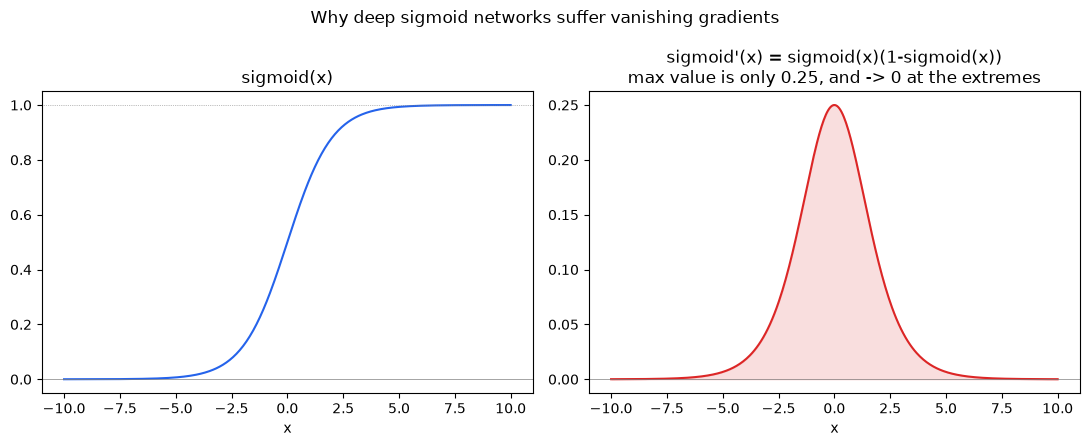

In [4]:
def visualize_vanishing_gradient(savepath: Path = None):
    x = np.linspace(-10, 10, 400)
    sig = 1 / (1 + np.exp(-x))
    sig_grad = sig * (1 - sig)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].plot(x, sig, color="#2563eb")
    axes[0].set_title("sigmoid(x)")
    axes[0].axhline(0, color="gray", linewidth=0.5)
    axes[0].axhline(1, color="gray", linewidth=0.5, linestyle=":")

    axes[1].plot(x, sig_grad, color="#dc2626")
    axes[1].set_title("sigmoid'(x) = sigmoid(x)(1-sigmoid(x))\nmax value is only 0.25, and -> 0 at the extremes")
    axes[1].axhline(0, color="gray", linewidth=0.5)
    axes[1].fill_between(x, sig_grad, alpha=0.15, color="#dc2626")

    for ax in axes:
        ax.set_xlabel("x")
    fig.suptitle("Why deep sigmoid networks suffer vanishing gradients")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

visualize_vanishing_gradient(FIG_DIR / "vanishing_gradient.png")

Sigmoid's derivative maxes out at **0.25**, and gets close to **0** whenever the input is far from zero (the function "saturates"). In a deep network, backprop multiplies one of these small numbers per layer — 10 layers of sigmoid activations could multiply the gradient by `0.25^10 ≈ 1e-6`, effectively killing the learning signal by the time it reaches early layers.

This is precisely *why* ReLU (`max(0, x)`, derivative is either 0 or exactly 1 — no shrinking in the active region) displaced sigmoid/tanh as the default hidden-layer activation, and why architectural tricks like residual connections (skip connections) and batch/layer normalization exist — they're explicit interventions to keep gradients from vanishing (or exploding) as they backpropagate through depth.

## Beyond first derivatives: Taylor series (brief)

Higher-order derivatives and multivariate Taylor expansion (MML §5.7–5.8) let you locally approximate any smooth function with a polynomial — the second-order (quadratic) term involves the **Hessian**, which is what second-order optimizers like Newton's method use, and what underlies the "curvature" intuition behind why some loss landscapes are easy or hard to optimize (flat regions, sharp valleys, saddle points). We'll come back to this directly in the next notebook on optimization.

---

## Self-check before moving on

- [ ] I can explain backprop as "the chain rule applied through a computational graph," in one sentence
- [ ] I can walk through a forward + backward pass on a small expression graph by hand
- [ ] I can derive the gradient of softmax + cross-entropy
- [ ] I can explain what vanishing gradients are and why sigmoid/tanh are prone to them
- [ ] I can name at least one architectural fix for vanishing/exploding gradients

Next: `03-optimization-gradient-descent-convexity.ipynb`